In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Sequence, Tuple, Union

import numpy as np
from PIL import Image, ImageOps

import torch
import torchvision.transforms.v2 as v2

import onnxruntime as ort

# Your attached file defines class mySSD with the helpers we need.
# It includes:
# - mySSD.create_default_boxes(...)
# - mySSD.decode_ssd(...)
# - mySSD.iou_nms(...)
from SSD_from_scratch import mySSD
import CarImageClass

from pathlib import Path


device = "cpu" # "cuda" if torch.cuda.is_available() else "cpu"

# desktop or laptop
machine = 'desktop'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
else:
    folder_path = Path(r"C:\Udacity_car_data\data")

train_path = folder_path / "train"
test_path = folder_path / "test"
train_path_simple = folder_path / "train_simple"
test_path_simple = folder_path / "test_simple"
train_path_oo = folder_path / "train_one_obj"
test_path_oo = folder_path / "test_one_obj"

In [ ]:
@dataclass(frozen=True)
class SSDPostprocessConfig:
    score_thresh: float = 0.30
    nms_thresh: float = 0.50
    max_per_img: int = 100
    class_agnostic: bool = False
    variances: Tuple[float, float] = (0.1, 0.2)  # (v_c, v_s)


class SSDInt8ONNXPredictor:
    """
    Pipeline:
      1) preprocess: RGB -> float32 -> resize 300x300 -> ImageNet normalize -> NCHW
      2) inference: ORT session.run -> (loc_all, conf_all)
      3) postprocess: mimic mySSD.predict() logic (threshold-before-decode, decode_ssd, iou_nms)
    """

    def __init__(
        self,
        onnx_model_path: str,
        class_names_fg: Sequence[str],
        providers: Sequence[str] | None = None,
        post_cfg: SSDPostprocessConfig = SSDPostprocessConfig(),
    ):
        """
        class_names_fg: foreground class names in the SAME order as your training labels
                        (length = C-1, where C includes background).
                        Example: ["car", "truck", "pedestrian", ...]
        """
        if len(class_names_fg) == 0:
            raise ValueError("class_names_fg must be non-empty (foreground classes only).")

        self.class_names_fg = list(class_names_fg)
        self.post_cfg = post_cfg

        if providers is None:
            providers = ["CPUExecutionProvider"]

        sess_opts = ort.SessionOptions()
        self.sess = ort.InferenceSession(onnx_model_path, sess_options=sess_opts, providers=list(providers))

        # Input / output names
        inputs = self.sess.get_inputs()
        if len(inputs) != 1:
            raise ValueError(f"Expected 1 input, got {len(inputs)}.")
        self.input_name = inputs[0].name

        out_names = [o.name for o in self.sess.get_outputs()]
        if "loc" not in out_names or "conf" not in out_names:
            raise ValueError(f"Expected outputs named 'loc' and 'conf'. Got: {out_names}")
        self.loc_name = "loc"
        self.conf_name = "conf"

        # Priors (8732,4) in normalized cxcywh, as in your model.
        # create_default_boxes() is your canonical SSD300 prior generator. :contentReference[oaicite:3]{index=3}
        self.priors_cxcywh = mySSD.create_default_boxes().to(dtype=torch.float32, device="cpu")  # (8732,4)

        # Preprocess exactly like your show_prediction_side_by_side pipeline:
        # ToImage -> ToDtype(float32, scale=True) -> Resize(300,300, antialias=True) -> Normalize(ImageNet)
        # :contentReference[oaicite:4]{index=4}
        self.preprocess_tfms = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Resize((300, 300), antialias=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
        ])

    def preprocess(self, image: Union[str, Image.Image, np.ndarray]) -> Tuple[np.ndarray, Tuple[int, int]]:
        """
        Returns:
          x: float32 numpy array shaped (1,3,300,300)
          (orig_w, orig_h)
        """
        pil = self._to_pil_rgb(image)
        pil = ImageOps.exif_transpose(pil)

        orig_w, orig_h = pil.size

        x_t = self.preprocess_tfms(pil)              # (3,300,300) float32
        x_t = x_t.unsqueeze(0).contiguous()          # (1,3,300,300)
        x = x_t.cpu().numpy().astype(np.float32)     # ORT input is tensor(float) in your model I/O
        return x, (orig_w, orig_h)

    def infer(self, x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        x: (1,3,300,300) float32
        returns:
          loc_all: (1,8732,4) float32
          conf_all: (1,8732,C) float32 logits
        """
        loc_all, conf_all = self.sess.run([self.loc_name, self.conf_name], {self.input_name: x})
        return loc_all, conf_all

    @torch.no_grad()
    def postprocess(
        self,
        loc_all: np.ndarray,
        conf_all: np.ndarray,
        orig_size: Tuple[int, int],
    ) -> Dict[str, Any]:
        """
        Returns dict:
          labels: list[str]
          scores: list[float]
          boxes : np.ndarray (K,4) xyxy in ORIGINAL image pixel coords
        """
        orig_w, orig_h = orig_size
        cfg = self.post_cfg

        # Squeeze batch
        if loc_all.ndim == 3:
            loc = loc_all[0]
        else:
            raise ValueError(f"loc_all must have shape (1,P,4). Got {loc_all.shape}")

        if conf_all.ndim == 3:
            conf = conf_all[0]
        else:
            raise ValueError(f"conf_all must have shape (1,P,C). Got {conf_all.shape}")

        # To torch CPU
        loc_t = torch.from_numpy(loc).to(dtype=torch.float32, device="cpu")    # (P,4)
        conf_t = torch.from_numpy(conf).to(dtype=torch.float32, device="cpu")  # (P,C)

        P, C = conf_t.shape
        if self.priors_cxcywh.shape[0] != P:
            raise ValueError(f"Prior count mismatch: priors={self.priors_cxcywh.shape[0]} vs outputs P={P}")

        num_fg = C - 1
        if len(self.class_names_fg) != num_fg:
            raise ValueError(
                f"class_names_fg length must be C-1={num_fg}. "
                f"Got {len(self.class_names_fg)}."
            )

        # This mirrors your mySSD.predict:
        # scores_all = softmax(conf)[..., 1:] and threshold-before-decode. :contentReference[oaicite:5]{index=5}
        scores_fg = conf_t.softmax(dim=-1)[..., 1:]  # (P, C-1)

        keep_mask = scores_fg > cfg.score_thresh
        if not keep_mask.any():
            return {"labels": [], "scores": [], "boxes": np.zeros((0, 4), dtype=np.float32)}

        pri_idx, cls0_idx = keep_mask.nonzero(as_tuple=True)  # (M,), (M,)
        loc_sel = loc_t[pri_idx]                              # (M,4)
        pri_sel = self.priors_cxcywh[pri_idx]                 # (M,4)

        # decode_ssd produces normalized cxcywh. :contentReference[oaicite:6]{index=6}
        boxes_cxcywh = mySSD.decode_ssd(loc=loc_sel, priors=pri_sel, variances=cfg.variances)  # (M,4)

        # Convert to xyxy in 300x300 model pixel coords exactly as your predict does. :contentReference[oaicite:7]{index=7}
        cx, cy, w, h = boxes_cxcywh.unbind(dim=1)
        x1 = (cx - 0.5 * w).clamp(0, 1) * 300.0
        y1 = (cy - 0.5 * h).clamp(0, 1) * 300.0
        x2 = (cx + 0.5 * w).clamp(0, 1) * 300.0
        y2 = (cy + 0.5 * h).clamp(0, 1) * 300.0
        sel_boxes_300 = torch.stack([x1, y1, x2, y2], dim=1)  # (M,4)

        sel_scores = scores_fg[pri_idx, cls0_idx]   # (M,)
        sel_labels0 = cls0_idx.to(torch.int64)      # (M,) 0-based foreground labels

        # NMS identical to your predict logic (class-agnostic optional). :contentReference[oaicite:8]{index=8}
        if cfg.class_agnostic:
            keep = mySSD.iou_nms(sel_boxes_300, sel_scores, iou_threshold=cfg.nms_thresh)
            keep = keep[sel_scores[keep].argsort(descending=True)]
        else:
            order = torch.argsort(sel_labels0)
            boxes = sel_boxes_300[order]
            scores = sel_scores[order]
            labels = sel_labels0[order]

            kept = []
            i = 0
            N = labels.numel()
            while i < N:
                c = labels[i].item()
                j = i + 1
                while j < N and labels[j].item() == c:
                    j += 1
                local_keep = mySSD.iou_nms(boxes[i:j], scores[i:j], iou_threshold=cfg.nms_thresh)
                kept.append(torch.arange(i, j, device=boxes.device)[local_keep])
                i = j

            keep = torch.cat(kept, dim=0)
            keep = order[keep]
            keep = keep[sel_scores[keep].argsort(descending=True)]

        keep = keep[: cfg.max_per_img]

        boxes_300 = sel_boxes_300[keep]   # (K,4) in 300x300 coords
        scores_out = sel_scores[keep]
        labels0_out = sel_labels0[keep]

        # Scale boxes from 300x300 to ORIGINAL image pixel coords
        sx = float(orig_w) / 300.0
        sy = float(orig_h) / 300.0
        boxes_orig = boxes_300.clone()
        boxes_orig[:, [0, 2]] *= sx
        boxes_orig[:, [1, 3]] *= sy

        # Output format
        labels_str = [self.class_names_fg[int(i)] for i in labels0_out.tolist()]
        scores_list = [float(s) for s in scores_out.tolist()]
        boxes_np = boxes_orig.cpu().numpy().astype(np.float32)

        return {"labels": labels_str, "scores": scores_list, "boxes": boxes_np}

    def __call__(self, image: Union[str, Image.Image, np.ndarray]) -> Dict[str, Any]:
        x, orig_size = self.preprocess(image)
        loc_all, conf_all = self.infer(x)
        return self.postprocess(loc_all, conf_all, orig_size)

    @staticmethod
    def _to_pil_rgb(image: Union[str, Image.Image, np.ndarray]) -> Image.Image:
        if isinstance(image, str):
            return Image.open(image).convert("RGB")
        if isinstance(image, Image.Image):
            return image.convert("RGB")
        if isinstance(image, np.ndarray):
            arr = image
            if arr.ndim != 3 or arr.shape[2] != 3:
                raise ValueError(f"Expected HxWx3 numpy image, got shape {arr.shape}")
            # Assume it's already RGB; if you pass BGR (cv2), convert before calling:
            # arr = arr[..., ::-1]
            return Image.fromarray(arr.astype(np.uint8), mode="RGB")
        raise TypeError(f"Unsupported image type: {type(image)}")


In [51]:
ssd_model_noZO_BS = mySSD(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                          in_channels=3,
                          variances=(0.1, 0.2))

WEIGHTS_PATH = r"C:\Users\eblac\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
ssd_model_noZO_BS.load_state_dict(state_dict, strict=False)
ssd_model_noZO_BS.to(device='cpu')

predictor = SSDInt8ONNXPredictor(
    onnx_model_path=r"C:\Users\eblac\Documents\GitHub\self-driving-car\PTQ_testing\ssd_int8.onnx",
    class_names_fg=["biker", "car", "pedestrian", "trafficLight", "truck"],
)


test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

test_data = CarImageClass.ImageClass(targ_dir=test_path, transform=test_tfms, file_pct=1)

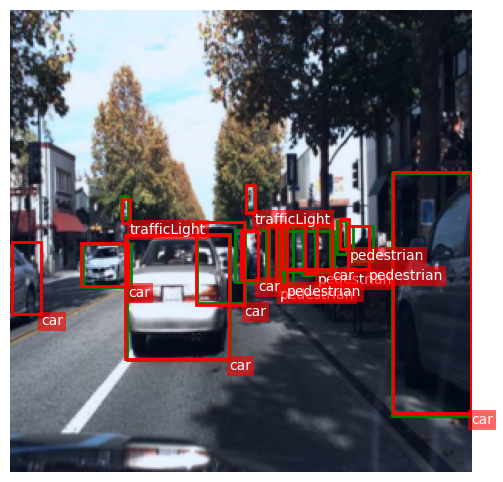

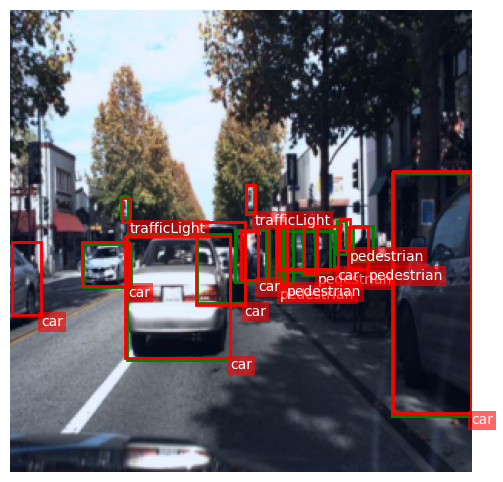

In [63]:
idx = np.random.randint(0, len(test_data))

testpred = ssd_model_noZO_BS.predict(test_data[idx][0].unsqueeze(dim=0),
                                     score_thresh=0.3,
                                     nms_thresh=0.5,
                                     max_per_img=100)

test_data.show_with_box(index=idx, color='g', lw=2, label=False, pred_dict=testpred[0], pred_color='r', lw_pred=2, pred_label=True);
test_data.show_with_box(index=idx, color='g', lw=2, label=False, pred_dict=predictor(str(test_data.paths[idx])), pred_color='r', lw_pred=2, pred_label=True, pred_size=(512,512));

In [49]:
predictor(str(test_data.paths[idx]))

{'labels': ['car', 'car', 'car', 'car', 'car', 'car', 'car'],
 'scores': [0.7147639393806458,
  0.26114022731781006,
  0.2493535280227661,
  0.22801603376865387,
  0.22357037663459778,
  0.2141609638929367,
  0.20451699197292328],
 'boxes': array([[285.15222 , 164.19583 , 300.4657  , 185.14531 ],
        [106.89624 , 134.62863 , 358.7252  , 423.7499  ],
        [160.25116 ,  81.0179  , 407.77032 , 370.1392  ],
        [106.89624 ,  34.702637, 358.7252  , 318.87592 ],
        [155.68553 , 175.92923 , 407.51447 , 475.20642 ],
        [ 58.10698 ,  81.0179  , 309.9359  , 370.1392  ],
        [104.48553 , 224.975   , 356.31445 , 512.      ]], dtype=float32)}

In [17]:
test_data.paths[idx]

WindowsPath('C:/Udacity_car_data/data/test/1478901399850333911_jpg.rf.46a4dd5199a7babb2a0003fcd232f608.jpg')

In [19]:
str(test_data.paths[idx])

'C:\\Udacity_car_data\\data\\test\\1478901399850333911_jpg.rf.46a4dd5199a7babb2a0003fcd232f608.jpg'

In [20]:
out = predictor(str(test_data.paths[idx]))
out

{'labels': ['car',
  'car',
  'car',
  'car',
  'trafficLight',
  'trafficLight',
  'trafficLight',
  'car',
  'trafficLight',
  'car',
  'trafficLight',
  'car',
  'car',
  'car',
  'car',
  'trafficLight',
  'trafficLight',
  'trafficLight',
  'trafficLight',
  'car'],
 'scores': [0.9999998807907104,
  0.9999994039535522,
  0.997865617275238,
  0.9899000525474548,
  0.9874956011772156,
  0.9843265414237976,
  0.9760435223579407,
  0.9697217345237732,
  0.96513432264328,
  0.9095198512077332,
  0.8981168270111084,
  0.8209753036499023,
  0.8027546405792236,
  0.5340755581855774,
  0.5280933976173401,
  0.46025851368904114,
  0.4114605188369751,
  0.38520172238349915,
  0.3032185733318329,
  0.23353977501392365],
 'boxes': array([[384.89948 , 235.63579 , 509.505   , 349.93765 ],
        [119.279205, 236.75584 , 237.59613 , 370.26907 ],
        [395.72214 , 255.2302  , 504.9287  , 414.88358 ],
        [432.58652 , 263.14905 , 508.83646 , 508.25174 ],
        [166.03291 , 139.4057  , 175

In [43]:
isinstance(out['labels'][0], str)

True

In [45]:
isinstance(testpred[0]['labels'][0], float)

False

In [37]:
testpred

[{'labels': tensor([1, 1, 1]),
  'scores': tensor([0.9937, 0.7138, 0.4344]),
  'boxes': tensor([[249.0579, 128.1533, 298.8650, 237.9797],
          [181.6540, 134.8809, 211.4644, 170.6953],
          [135.0346, 139.1278, 158.2893, 162.7912]])}]

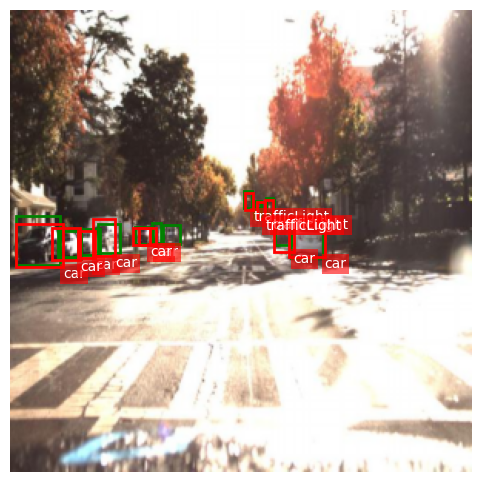

In [24]:
test_data.show_with_box(index=idx, color='g', lw=2, label=False, pred_dict=predictor(str(test_data.paths[idx])), pred_color='r', lw_pred=2, pred_label=True, pred_size=(512,512));

In [72]:
import numpy as np
import onnx
from onnx import helper, numpy_helper, TensorProto


def stitch_ssd_decode_nms(
    model_in: str,
    model_out: str,
    priors_cxcywh: np.ndarray,     # (8732,4) float32 normalized
    num_classes_with_bg: int = 6,  # conf last dim
    score_threshold: float = 0.20,
    iou_threshold: float = 0.50,
    max_output_boxes_per_class: int = 50,
    variances=(0.1, 0.2),
    opset: int = 13,
):
    m = onnx.load(model_in)
    g = m.graph

    # Expect outputs named exactly 'loc' and 'conf'
    loc_name = "loc"
    conf_name = "conf"
    out_names = {o.name for o in g.output}
    if loc_name not in out_names or conf_name not in out_names:
        raise ValueError(f"Graph outputs are {sorted(out_names)}; expected 'loc' and 'conf'.")

    # Remove original outputs
    del g.output[:]

    # --- initializers ---
    priors_cxcywh = np.asarray(priors_cxcywh, dtype=np.float32)
    if priors_cxcywh.shape != (8732, 4):
        raise ValueError(f"priors must be (8732,4), got {priors_cxcywh.shape}")

    g.initializer.append(numpy_helper.from_array(priors_cxcywh, name="priors_cxcywh"))

    v0 = np.array([variances[0]], dtype=np.float32)
    v1 = np.array([variances[1]], dtype=np.float32)
    g.initializer.append(numpy_helper.from_array(v0, name="var0"))
    g.initializer.append(numpy_helper.from_array(v1, name="var1"))

    half = np.array([0.5], dtype=np.float32)
    zero_f = np.array([0.0], dtype=np.float32)
    one_f = np.array([1.0], dtype=np.float32)
    g.initializer.append(numpy_helper.from_array(half, name="half"))
    g.initializer.append(numpy_helper.from_array(zero_f, name="zero_f"))
    g.initializer.append(numpy_helper.from_array(one_f, name="one_f"))

    max_out = np.array([max_output_boxes_per_class], dtype=np.int64)
    iou_thr = np.array([iou_threshold], dtype=np.float32)
    score_thr = np.array([score_threshold], dtype=np.float32)
    g.initializer.append(numpy_helper.from_array(max_out, name="max_out"))
    g.initializer.append(numpy_helper.from_array(iou_thr, name="iou_thr"))
    g.initializer.append(numpy_helper.from_array(score_thr, name="score_thr"))

    unsq_axes0 = np.array([0], dtype=np.int64)
    g.initializer.append(numpy_helper.from_array(unsq_axes0, name="unsq_axes0"))

    sq_axes1 = np.array([1], dtype=np.int64)
    g.initializer.append(numpy_helper.from_array(sq_axes1, name="sq_axes1"))


    # column selectors for selected_indices
    cols_box = np.array([0, 2], dtype=np.int64)
    col_cls = np.array([1], dtype=np.int64)
    g.initializer.append(numpy_helper.from_array(cols_box, name="cols_box"))
    g.initializer.append(numpy_helper.from_array(col_cls, name="col_cls"))

    # Slice params to drop background class at axis=2: [1, C]
    starts = np.array([1], dtype=np.int64)
    ends = np.array([num_classes_with_bg], dtype=np.int64)
    axes = np.array([2], dtype=np.int64)
    g.initializer.append(numpy_helper.from_array(starts, name="slice_starts"))
    g.initializer.append(numpy_helper.from_array(ends, name="slice_ends"))
    g.initializer.append(numpy_helper.from_array(axes, name="slice_axes"))

    # --- nodes ---
    nodes = []

    # priors: (8732,4) -> (1,8732,4) -> expand to shape(loc): (B,8732,4)
    nodes.append(helper.make_node("Unsqueeze", ["priors_cxcywh", "unsq_axes0"], ["priors_u"]))
    nodes.append(helper.make_node("Shape", [loc_name], ["loc_shape"]))
    nodes.append(helper.make_node("Expand", ["priors_u", "loc_shape"], ["priors_bp4"]))

    # Split loc and priors into components along last axis
    nodes.append(helper.make_node("Split", [loc_name], ["dx", "dy", "dw", "dh"], axis=2))
    nodes.append(helper.make_node("Split", ["priors_bp4"], ["pcx", "pcy", "pw", "ph"], axis=2))

    # cx = pcx + dx*var0*pw
    nodes.append(helper.make_node("Mul", ["dx", "pw"], ["dx_pw"]))
    nodes.append(helper.make_node("Mul", ["dx_pw", "var0"], ["dx_pw_v0"]))
    nodes.append(helper.make_node("Add", ["pcx", "dx_pw_v0"], ["cx"]))

    # cy = pcy + dy*var0*ph
    nodes.append(helper.make_node("Mul", ["dy", "ph"], ["dy_ph"]))
    nodes.append(helper.make_node("Mul", ["dy_ph", "var0"], ["dy_ph_v0"]))
    nodes.append(helper.make_node("Add", ["pcy", "dy_ph_v0"], ["cy"]))

    # w = pw * exp(dw*var1)
    nodes.append(helper.make_node("Mul", ["dw", "var1"], ["dw_v1"]))
    nodes.append(helper.make_node("Exp", ["dw_v1"], ["exp_dw"]))
    nodes.append(helper.make_node("Mul", ["pw", "exp_dw"], ["w"]))

    # h = ph * exp(dh*var1)
    nodes.append(helper.make_node("Mul", ["dh", "var1"], ["dh_v1"]))
    nodes.append(helper.make_node("Exp", ["dh_v1"], ["exp_dh"]))
    nodes.append(helper.make_node("Mul", ["ph", "exp_dh"], ["h"]))

    # x1 = cx - 0.5*w ; x2 = cx + 0.5*w
    nodes.append(helper.make_node("Mul", ["w", "half"], ["w_half"]))
    nodes.append(helper.make_node("Sub", ["cx", "w_half"], ["x1"]))
    nodes.append(helper.make_node("Add", ["cx", "w_half"], ["x2"]))

    # y1 = cy - 0.5*h ; y2 = cy + 0.5*h
    nodes.append(helper.make_node("Mul", ["h", "half"], ["h_half"]))
    nodes.append(helper.make_node("Sub", ["cy", "h_half"], ["y1"]))
    nodes.append(helper.make_node("Add", ["cy", "h_half"], ["y2"]))

    # concat boxes as (B,8732,4) in xyxy normalized, then Clip to [0,1]
    nodes.append(helper.make_node("Concat", ["x1", "y1", "x2", "y2"], ["boxes_xyxy"], axis=2))
    nodes.append(helper.make_node("Clip", ["boxes_xyxy", "zero_f", "one_f"], ["boxes_clip"]))

    # probs = softmax(conf, axis=2)
    nodes.append(helper.make_node("Softmax", [conf_name], ["probs"], axis=2))

    # drop background: probs[:,:,1:] -> (B,8732,C-1)
    nodes.append(helper.make_node("Slice", ["probs", "slice_starts", "slice_ends", "slice_axes"], ["probs_fg"]))

    # scores for NMS: (B,C-1,8732)
    nodes.append(helper.make_node("Transpose", ["probs_fg"], ["scores_nms"], perm=[0, 2, 1]))

    # NMS: selected_indices (N,3): [batch, class, box]
    nodes.append(helper.make_node(
        "NonMaxSuppression",
        ["boxes_clip", "scores_nms", "max_out", "iou_thr", "score_thr"],
        ["selected_indices"],
        center_point_box=0,
    ))

    # Build indices for boxes gather: selected_indices[:, [0,2]] -> (N,2)
    nodes.append(helper.make_node("Gather", ["selected_indices", "cols_box"], ["idx_box"], axis=1))
    # Gather selected boxes: (N,4)
    nodes.append(helper.make_node("GatherND", ["boxes_clip", "idx_box"], ["boxes_out"]))

    # Gather selected scores: GatherND(scores_nms, selected_indices) -> (N)
    nodes.append(helper.make_node("GatherND", ["scores_nms", "selected_indices"], ["scores_out"]))

    # Labels: selected_indices[:,1] -> (N)
    nodes.append(helper.make_node("Gather", ["selected_indices", "col_cls"], ["labels_out_u"], axis=1))
    nodes.append(helper.make_node("Squeeze", ["labels_out_u", "sq_axes1"], ["labels_out"]))

    # Append nodes to graph
    g.node.extend(nodes)

    # Set new outputs
    g.output.extend([
        helper.make_tensor_value_info("boxes_out", TensorProto.FLOAT, [None, 4]),
        helper.make_tensor_value_info("scores_out", TensorProto.FLOAT, [None]),
        helper.make_tensor_value_info("labels_out", TensorProto.INT64, [None]),
    ])

    # Ensure opset is at least what we need (without slice assignment)
    target = int(opset)

    found = False
    for imp in m.opset_import:
        if imp.domain == "":
            # Usually safest to NOT lower an existing opset
            imp.version = max(int(imp.version), target)
            found = True
            break

    if not found:
        m.opset_import.extend([helper.make_opsetid("", target)])


    onnx.checker.check_model(m)
    onnx.save(m, model_out)


if __name__ == "__main__":
    # Example: priors from your own generator (recommended)
    # priors = mySSD.create_default_boxes().cpu().numpy().astype(np.float32)
    # stitch_ssd_decode_nms("ssd_int8.onnx", "ssd_int8_with_post.onnx", priors)

    pass


In [73]:
priors = mySSD.create_default_boxes().cpu().numpy().astype(np.float32)

In [74]:
stitch_ssd_decode_nms(
    model_in=r"C:\Users\eblac\Documents\GitHub\self-driving-car\PTQ_testing\ssd_int8.onnx",
    model_out=r"C:\Users\eblac\Documents\GitHub\self-driving-car\PTQ_testing\ssd_int8_with_pre_post.onnx",
    priors_cxcywh=priors,
    num_classes_with_bg=6,
    score_threshold=0.30,
    iou_threshold=0.50,
    max_output_boxes_per_class=50,
    variances=(0.1, 0.2),
    opset=13,
)


In [ ]:
import cv2

def probe_cameras(max_idx=10, backend=cv2.CAP_DSHOW):
    for i in range(max_idx):
        cap = cv2.VideoCapture(i, backend)
        if not cap.isOpened():
            cap.release()
            continue

        ok, frame = cap.read()
        w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
        h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        fps = cap.get(cv2.CAP_PROP_FPS)

        print(f"[{i}] opened  {int(w)}x{int(h)}  fps={fps:.1f}  ok={ok}")

        if ok:
            cv2.imshow(f"cam {i} (press any key)", frame)
            cv2.waitKey(0)
            cv2.destroyWindow(f"cam {i} (press any key)")

        cap.release()

probe_cameras(max_idx=10)


[0] opened  640x480  fps=0.0  ok=True
